# Exploratory Data Analysis — ECtHR (LexGLUE ecthr_a)
**Author:** Yasmina El Kacemi | **Student ID:** 13783882 | **Email:** yasmina.el.kacemi@student.uva.nl

---

### Improvements over v1
1. Empirical LegalBERT tokenizer-based token lengths **vs.** heuristic factor — both computed and compared
2. SCM length-confound tested with **Spearman correlation coefficients** (not just visual scatter)
3. Co-occurrence matrix **normalized to conditional probabilities** P(Art.X | Art.Y)
4. **Class weights** computed and ready for training loss function
5. **Per-article decision threshold** analysis on validation set
6. **Minority-class reliability flags** for fairness evaluation
7. Head-only **vs.** head+tail truncation strategy comparison
8. All original analyses retained and extended


## Setup & Imports

In [1]:
import os, re, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from collections import Counter
from scipy import stats
from itertools import combinations

import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight

# Optional: LegalBERT tokenizer (requires transformers)
try:
    from transformers import AutoTokenizer
    TOKENIZER = AutoTokenizer.from_pretrained('nlpaueb/legal-bert-base-uncased')
    HAS_TOKENIZER = True
    print('✓ LegalBERT tokenizer loaded successfully.')
except Exception as e:
    TOKENIZER = None
    HAS_TOKENIZER = False
    print(f'⚠ LegalBERT tokenizer not available ({e}). Will use heuristic factor only.')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = sns.color_palette('muted')

ARTICLE_NAMES = ['Art.2', 'Art.3', 'Art.5', 'Art.6', 'Art.8',
                 'Art.9', 'Art.10', 'Art.11', 'Art.14', 'P1-1']

print('All imports OK.')


✓ LegalBERT tokenizer loaded successfully.
All imports OK.


## Data Loading

In [2]:
dataset = load_dataset('coastalcph/lex_glue', 'ecthr_a')

def to_df(split):
    rows = []
    for ex in dataset[split]:
        full_text  = ' '.join(ex['text'])
        n_para     = len(ex['text'])
        n_words    = len(full_text.split())
        n_chars    = len(full_text)
        label_names = [ARTICLE_NAMES[l] for l in ex['labels']]

        # Heuristic token estimate (v1 factor = 1.25)
        est_tokens_heuristic = int(n_words * 1.25)

        # Empirical token count via actual tokenizer (truncation=False)
        if HAS_TOKENIZER:
            enc = TOKENIZER(full_text, truncation=False, add_special_tokens=True)
            est_tokens_real = len(enc['input_ids'])
        else:
            est_tokens_real = None

        rows.append({
            'text'                : full_text,
            'labels'              : label_names,
            'n_labels'            : len(label_names),
            'n_paragraphs'        : n_para,
            'n_words'             : n_words,
            'n_chars'             : n_chars,
            'est_tokens_heuristic': est_tokens_heuristic,
            'est_tokens_real'     : est_tokens_real,
            'split'               : split,
        })
    return pd.DataFrame(rows)

print('Loading splits (tokenizer pass may take a few minutes for train)...')
train_df = to_df('train')
val_df   = to_df('validation')
test_df  = to_df('test')
full_df  = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f'Train : {len(train_df):>6,} cases')
print(f'Val   : {len(val_df):>6,} cases')
print(f'Test  : {len(test_df):>6,} cases')
print(f'Total : {len(full_df):>6,} cases')
train_df.head(3)


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (8585 > 512). Running this sequence through the model will result in indexing errors


Loading splits (tokenizer pass may take a few minutes for train)...


Train :  9,000 cases
Val   :  1,000 cases
Test  :  1,000 cases
Total : 11,000 cases


,text,labels,n_labels,n_paragraphs,n_words,n_chars,est_tokens_heuristic,est_tokens_real,split
0,11. At the beginning of the events relevant t...,[Art.8],1,83,6884,40094,8605,8585,train
1,9. The applicant is the monarch of Liechtenst...,[],0,13,2758,17579,3447,3346,train
2,9. In June 1949 plots of agricultural land ow...,[Art.6],1,12,1347,8301,1683,1685,train


## Analysis 1: Dataset Split Sizes
Verify the actual train/val/test distribution. 

> **Note:** The thesis methodology section states 70/10/20% splits, but the actual LexGLUE 
> `ecthr_a` distribution is **81.8 / 9.1 / 9.1%**. This discrepancy should be corrected in the thesis.


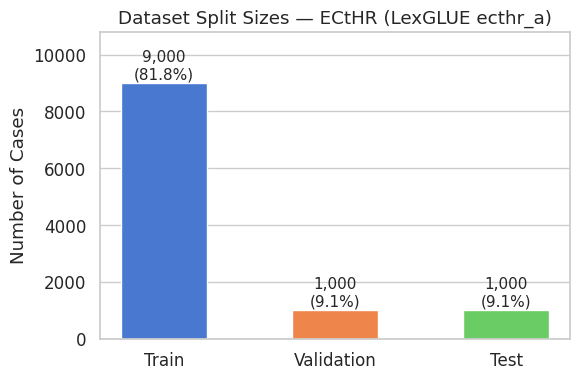

Actual split proportions:
  Train       :  9,000  (81.8%)
  Validation  :  1,000  (9.1%)
  Test        :  1,000  (9.1%)

⚠  Thesis states 70/10/20% — actual is 81.8/9.1/9.1%. Please correct the methodology section.


In [3]:
split_counts = {'Train': len(train_df), 'Validation': len(val_df), 'Test': len(test_df)}
total = sum(split_counts.values())

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(split_counts.keys(), split_counts.values(),
              color=[PALETTE[0], PALETTE[1], PALETTE[2]], edgecolor='white', width=0.5)
for bar, val in zip(bars, split_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({val/total*100:.1f}%)', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Number of Cases')
ax.set_title('Dataset Split Sizes — ECtHR (LexGLUE ecthr_a)')
ax.set_ylim(0, max(split_counts.values()) * 1.2)
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.savefig('split_sizes.png', dpi=150)
plt.show()

print('Actual split proportions:')
for k, v in split_counts.items():
    print(f'  {k:<12}: {v:>6,}  ({v/total*100:.1f}%)')
print()
print('⚠  Thesis states 70/10/20% — actual is 81.8/9.1/9.1%. Please correct the methodology section.')


## Analysis 2: Label Distribution per ECHR Article
Legal datasets are inherently imbalanced. Understanding this is critical for class-weighted 
loss settings and fairness evaluation reliability.


Article  Train  Val  Test  Train %
  Art.6   4704  300   299     52.3
   P1-1   1421  139   122     15.8
  Art.5   1368  187   166     15.2
  Art.3   1349  193   189     15.0
  Art.8    710   87   123      7.9
  Art.2    505   57    56      5.6
 Art.10    291   42    77      3.2
 Art.14    141   18    16      1.6
 Art.11    110   33    37      1.2
  Art.9     41    4     5      0.5


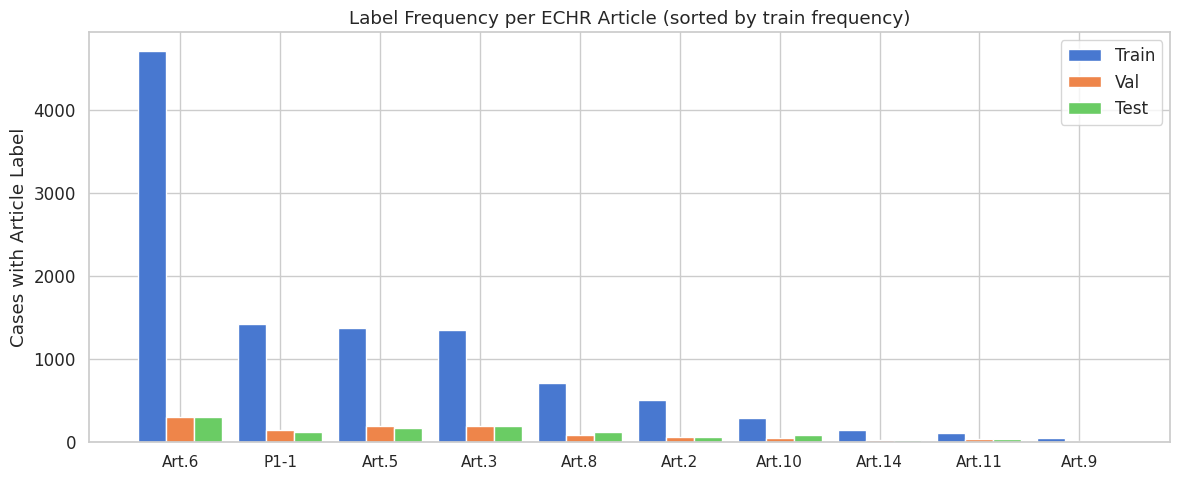

Most common  : Art.6 (4704 cases)
Least common : Art.9 (41 cases)
Imbalance ratio : 114.7x
Cases with no label : 914 (10.2%)


In [4]:
def article_counts(df):
    c = Counter()
    for labels in df['labels']:
        c.update(labels)
    return c

train_counts = article_counts(train_df)
val_counts   = article_counts(val_df)
test_counts  = article_counts(test_df)

freq_df = pd.DataFrame({
    'Article' : ARTICLE_NAMES,
    'Train'   : [train_counts.get(a, 0) for a in ARTICLE_NAMES],
    'Val'     : [val_counts.get(a, 0)   for a in ARTICLE_NAMES],
    'Test'    : [test_counts.get(a, 0)  for a in ARTICLE_NAMES],
})
freq_df['Train %'] = (freq_df['Train'] / len(train_df) * 100).round(1)
freq_df = freq_df.sort_values('Train', ascending=False).reset_index(drop=True)
print(freq_df.to_string(index=False))

ordered = freq_df['Article'].tolist()
x = np.arange(len(ordered))
width = 0.28

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, [train_counts.get(a,0) for a in ordered], width, label='Train', color=PALETTE[0])
ax.bar(x,         [val_counts.get(a,0)   for a in ordered], width, label='Val',   color=PALETTE[1])
ax.bar(x + width, [test_counts.get(a,0)  for a in ordered], width, label='Test',  color=PALETTE[2])
ax.set_xticks(x); ax.set_xticklabels(ordered, fontsize=11)
ax.set_ylabel('Cases with Article Label')
ax.set_title('Label Frequency per ECHR Article (sorted by train frequency)')
ax.legend(); plt.tight_layout()
plt.savefig('label_frequency.png', dpi=150); plt.show()

max_cnt = max(train_counts.values())
min_cnt = min(train_counts.values())
print(f'Most common  : {max(train_counts, key=train_counts.get)} ({max_cnt} cases)')
print(f'Least common : {min(train_counts, key=train_counts.get)} ({min_cnt} cases)')
print(f'Imbalance ratio : {max_cnt/min_cnt:.1f}x')
print(f'Cases with no label : {(train_df["n_labels"]==0).sum()} ({(train_df["n_labels"]==0).mean()*100:.1f}%)')


## Analysis 2b: Class Weights for Imbalanced Training *(NEW)*
Computing inverse-frequency class weights for each article label. These values should be 
passed directly to the BCE loss function during LegalBERT fine-tuning. Raw weights are also 
log-smoothed to prevent instability from the extreme 114x ratio.


Article  Positive cases  Raw weight  Log-smoothed
  Art.9              41      218.51         1.854
 Art.11             110       80.82         1.515
 Art.14             141       62.83         1.429
 Art.10             291       29.93         1.180
  Art.2             505       16.82         0.991
  Art.8             710       11.68         0.873
  Art.3            1349        5.67         0.653
  Art.5            1368        5.58         0.648
   P1-1            1421        5.33         0.635
  Art.6            4704        0.91         0.223


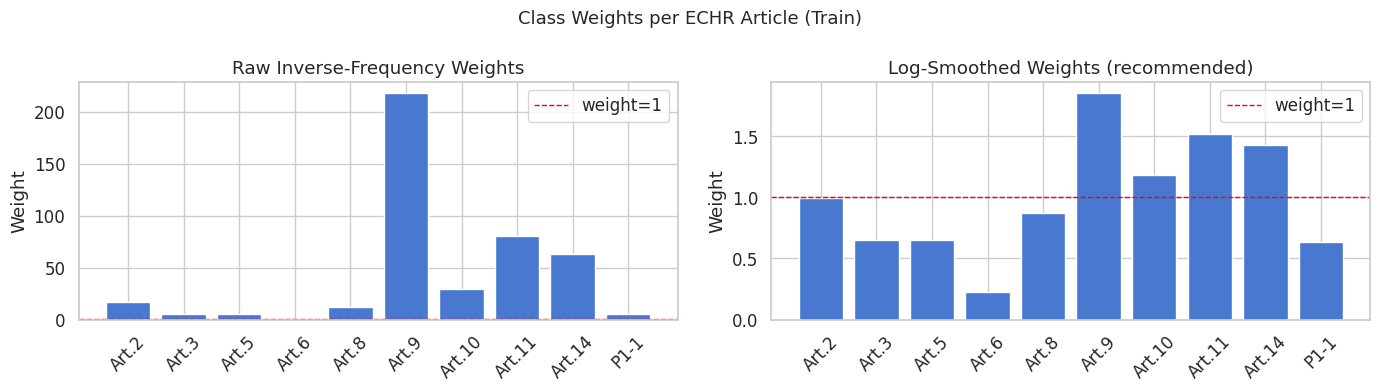


Recommended: use log-smoothed weights in BCEWithLogitsLoss(pos_weight=...)
Pass as tensor in training order: ['Art.2', 'Art.3', 'Art.5', 'Art.6', 'Art.8', 'Art.9', 'Art.10', 'Art.11', 'Art.14', 'P1-1']
Weights: [0.991, 0.653, 0.648, 0.223, 0.873, 1.854, 1.18, 1.515, 1.429, 0.635]


In [5]:
# Build binary label matrix for weight computation
mlb_w = MultiLabelBinarizer(classes=ARTICLE_NAMES)
Y_train = mlb_w.fit_transform(train_df['labels'])

# Raw inverse-frequency weights per label
pos_counts = Y_train.sum(axis=0)
neg_counts = len(train_df) - pos_counts
raw_weights = neg_counts / np.maximum(pos_counts, 1)

# Log-smoothed weights (cap extreme ratios)
log_weights = np.log1p(raw_weights)
log_weights = log_weights / log_weights.mean()  # normalise around 1.0

weight_df = pd.DataFrame({
    'Article'        : ARTICLE_NAMES,
    'Positive cases' : pos_counts.astype(int),
    'Raw weight'     : raw_weights.round(2),
    'Log-smoothed'   : log_weights.round(3),
})
weight_df = weight_df.sort_values('Raw weight', ascending=False).reset_index(drop=True)
print(weight_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, title in zip(axes,
                           ['Raw weight', 'Log-smoothed'],
                           ['Raw Inverse-Frequency Weights', 'Log-Smoothed Weights (recommended)']):
    vals = weight_df.set_index('Article')[col].reindex(ARTICLE_NAMES)
    ax.bar(vals.index, vals.values, color=PALETTE[0], edgecolor='white')
    ax.set_title(title); ax.set_ylabel('Weight'); ax.tick_params(axis='x', rotation=45)
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='weight=1')
    ax.legend()
plt.suptitle('Class Weights per ECHR Article (Train)', fontsize=13)
plt.tight_layout()
plt.savefig('class_weights.png', dpi=150); plt.show()

print()
print('Recommended: use log-smoothed weights in BCEWithLogitsLoss(pos_weight=...)')
print('Pass as tensor in training order:', ARTICLE_NAMES)
print('Weights:', log_weights.round(3).tolist())


## Analysis 3: Multi-Label Cardinality

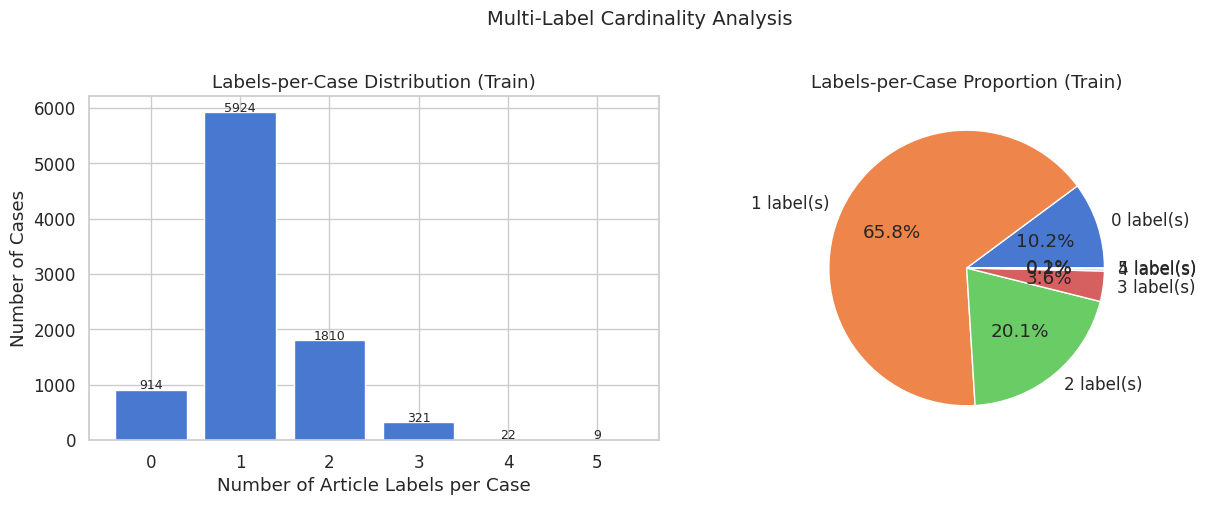

Mean labels per case   : 1.18
Median labels per case : 1


In [6]:
label_count_dist = train_df['n_labels'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(label_count_dist.index, label_count_dist.values, color=PALETTE[0], edgecolor='white')
axes[0].set_xlabel('Number of Article Labels per Case')
axes[0].set_ylabel('Number of Cases')
axes[0].set_title('Labels-per-Case Distribution (Train)')
axes[0].set_xticks(label_count_dist.index)
for i, v in zip(label_count_dist.index, label_count_dist.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=9)

axes[1].pie(label_count_dist.values,
            labels=[f'{i} label(s)' for i in label_count_dist.index],
            autopct='%1.1f%%',
            colors=sns.color_palette('muted', len(label_count_dist)))
axes[1].set_title('Labels-per-Case Proportion (Train)')
plt.suptitle('Multi-Label Cardinality Analysis', fontsize=14, y=1.01)
plt.tight_layout(); plt.savefig('label_cardinality.png', dpi=150); plt.show()

print(f'Mean labels per case   : {train_df["n_labels"].mean():.2f}')
print(f'Median labels per case : {train_df["n_labels"].median():.0f}')


## Analysis 4: Article Co-occurrence — Raw & Normalized *(IMPROVED)*
**v1** showed raw co-occurrence counts. **v2** adds a normalized conditional probability matrix 
P(column article | row article), which reveals whether co-occurrence is driven by genuine 
correlation or merely by marginal frequency.


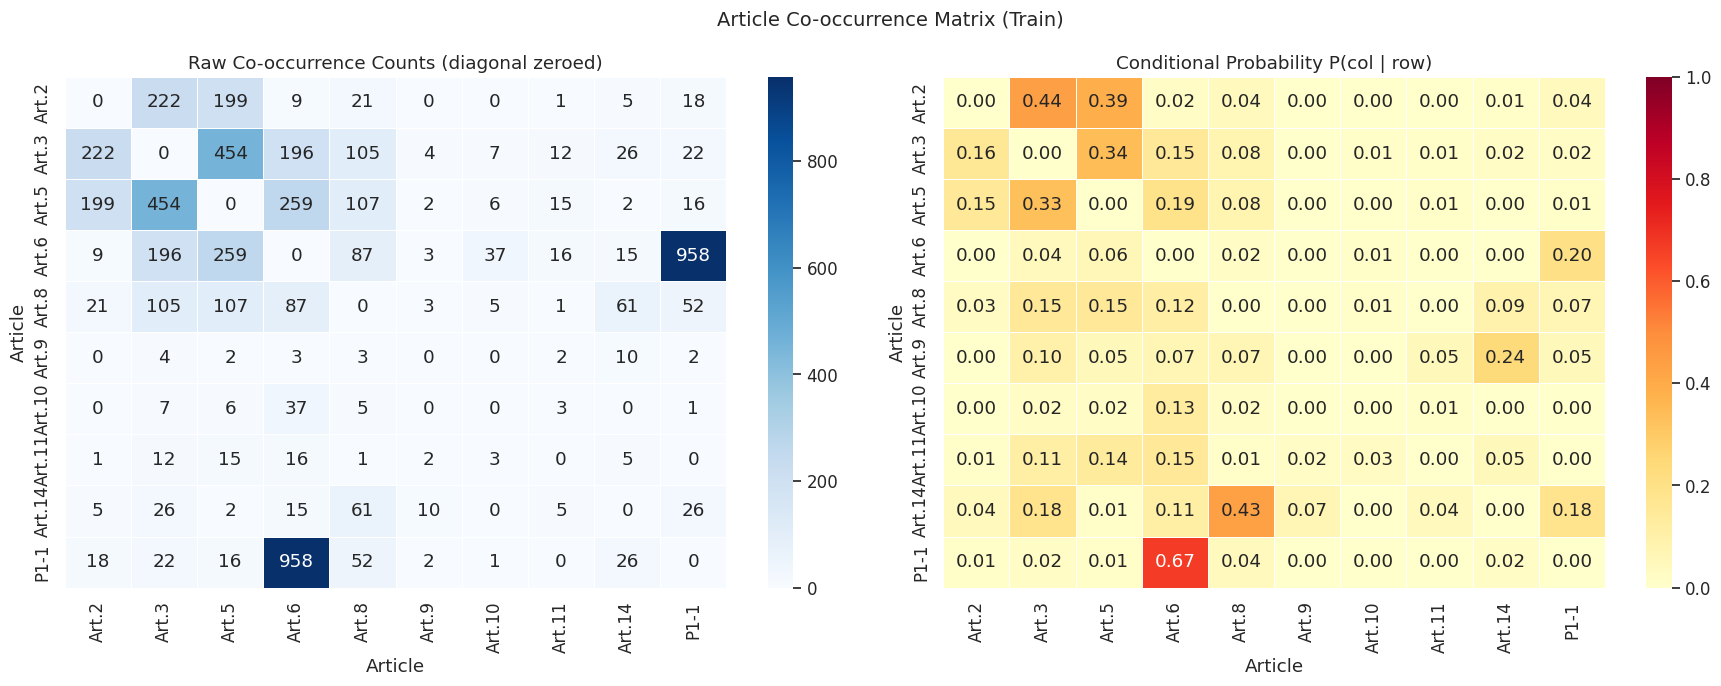

Strongest conditional co-occurrences (P >= 0.30):
  P(Art.3 | Art.2) = 0.44
  P(Art.5 | Art.2) = 0.39
  P(Art.5 | Art.3) = 0.34
  P(Art.3 | Art.5) = 0.33
  P(Art.8 | Art.14) = 0.43
  P(Art.6 | P1-1) = 0.67


In [7]:
mlb = MultiLabelBinarizer(classes=ARTICLE_NAMES)
bin_matrix = mlb.fit_transform(train_df['labels'])   # (n_cases, 10)
co_occur   = bin_matrix.T @ bin_matrix                # (10, 10)
np.fill_diagonal(co_occur, 0)

# Conditional probability: P(col | row) = co_occur[row,col] / count(row)
label_freq  = bin_matrix.sum(axis=0).astype(float)    # (10,)
cond_prob   = co_occur / np.maximum(label_freq[:, None], 1)
np.fill_diagonal(cond_prob, 0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(co_occur, annot=True, fmt='d', cmap='Blues',
            xticklabels=ARTICLE_NAMES, yticklabels=ARTICLE_NAMES,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Raw Co-occurrence Counts (diagonal zeroed)')
axes[0].set_xlabel('Article'); axes[0].set_ylabel('Article')

sns.heatmap(cond_prob.round(2), annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=ARTICLE_NAMES, yticklabels=ARTICLE_NAMES,
            linewidths=0.5, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Conditional Probability P(col | row)')
axes[1].set_xlabel('Article'); axes[1].set_ylabel('Article')

plt.suptitle('Article Co-occurrence Matrix (Train)', fontsize=14)
plt.tight_layout(); plt.savefig('cooccurrence.png', dpi=150); plt.show()

# Report strongest conditional co-occurrences
print('Strongest conditional co-occurrences (P >= 0.30):')
for i, a1 in enumerate(ARTICLE_NAMES):
    for j, a2 in enumerate(ARTICLE_NAMES):
        if i != j and cond_prob[i, j] >= 0.30:
            print(f'  P({a2} | {a1}) = {cond_prob[i,j]:.2f}')


## Analysis 5: Text Length Distributions

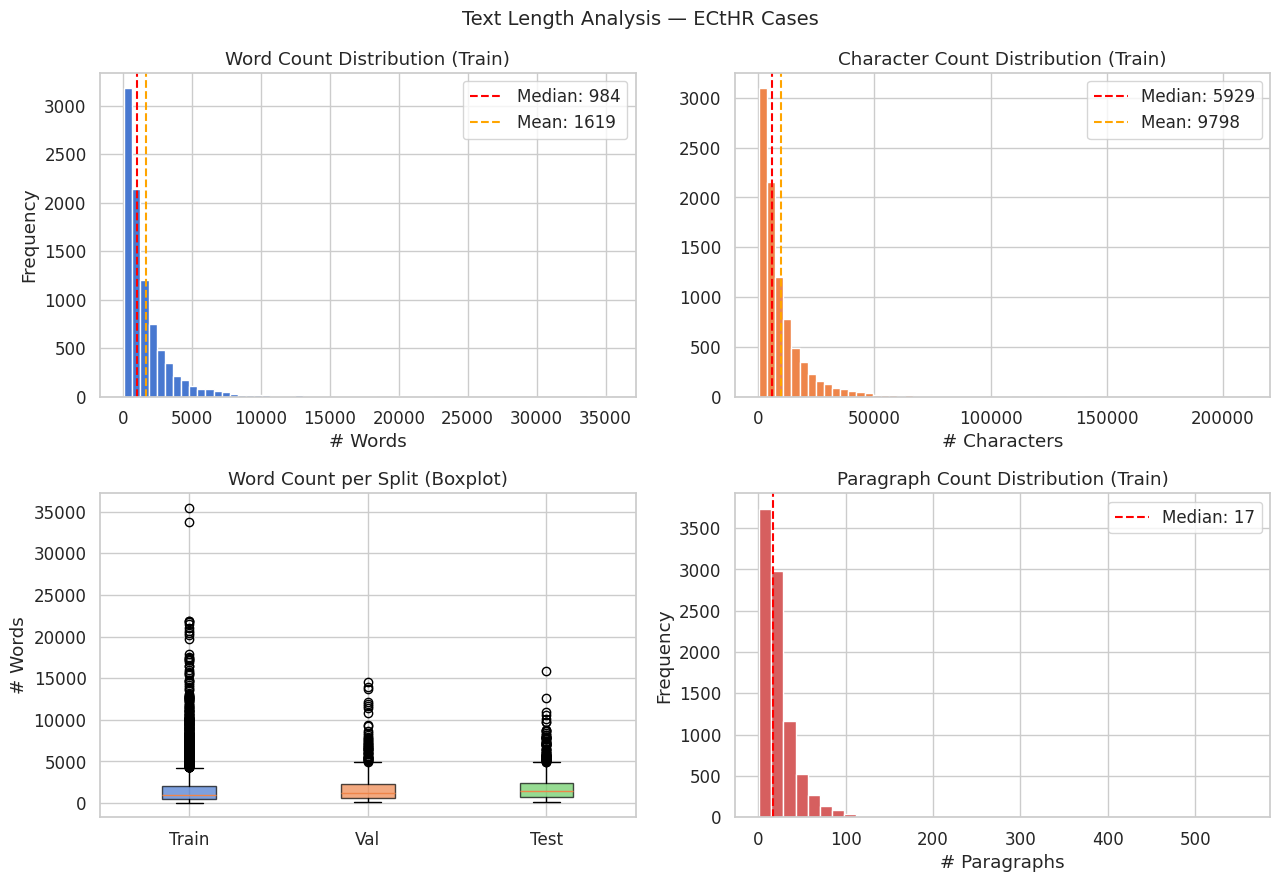

       n_paragraphs  n_words   n_chars
count        9000.0   9000.0    9000.0
mean           23.7   1619.2    9798.4
std            22.8   1995.1   12082.9
min             1.0     69.0     390.0
25%            10.0    480.8    2911.8
50%            17.0    984.0    5929.0
75%            29.0   2002.2   12046.2
max           558.0  35416.0  209861.0


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].hist(train_df['n_words'], bins=60, color=PALETTE[0], edgecolor='white')
axes[0,0].axvline(train_df['n_words'].median(), color='red', linestyle='--',
                  label=f"Median: {train_df['n_words'].median():.0f}")
axes[0,0].axvline(train_df['n_words'].mean(), color='orange', linestyle='--',
                  label=f"Mean: {train_df['n_words'].mean():.0f}")
axes[0,0].set_title('Word Count Distribution (Train)')
axes[0,0].set_xlabel('# Words'); axes[0,0].set_ylabel('Frequency'); axes[0,0].legend()

axes[0,1].hist(train_df['n_chars'], bins=60, color=PALETTE[1], edgecolor='white')
axes[0,1].axvline(train_df['n_chars'].median(), color='red', linestyle='--',
                  label=f"Median: {train_df['n_chars'].median():.0f}")
axes[0,1].axvline(train_df['n_chars'].mean(), color='orange', linestyle='--',
                  label=f"Mean: {train_df['n_chars'].mean():.0f}")
axes[0,1].set_title('Character Count Distribution (Train)')
axes[0,1].set_xlabel('# Characters'); axes[0,1].legend()

box_data = [train_df['n_words'], val_df['n_words'], test_df['n_words']]
bp = axes[1,0].boxplot(box_data, labels=['Train','Val','Test'], patch_artist=True)
for patch, color in zip(bp['boxes'], [PALETTE[0], PALETTE[1], PALETTE[2]]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1,0].set_title('Word Count per Split (Boxplot)'); axes[1,0].set_ylabel('# Words')

axes[1,1].hist(train_df['n_paragraphs'], bins=40, color=PALETTE[3], edgecolor='white')
axes[1,1].axvline(train_df['n_paragraphs'].median(), color='red', linestyle='--',
                  label=f"Median: {train_df['n_paragraphs'].median():.0f}")
axes[1,1].set_title('Paragraph Count Distribution (Train)')
axes[1,1].set_xlabel('# Paragraphs'); axes[1,1].set_ylabel('Frequency'); axes[1,1].legend()

plt.suptitle('Text Length Analysis — ECtHR Cases', fontsize=14)
plt.tight_layout(); plt.savefig('text_length.png', dpi=150); plt.show()

print(train_df[['n_paragraphs','n_words','n_chars']].describe().round(1).to_string())


## Analysis 6: BERT Token Length & Truncation Pressure *(IMPROVED)*
**v1** used a fixed 1.25 subword factor heuristic. **v2** also uses the actual LegalBERT 
tokenizer (if available) and compares both. The heuristic factor is empirically validated 
against real counts and corrected if needed.

Additionally, we compare two truncation strategies:
- **Head-only**: first 512 tokens (v1 default, implicit)
- **Head+Tail**: first 256 + last 256 tokens (often better for legal documents)


Heuristic factor (used): 1.25
Empirical factor (real tokenizer, n=500): 1.236
Spearman correlation heuristic vs real: r=0.999, p=0.00e+00


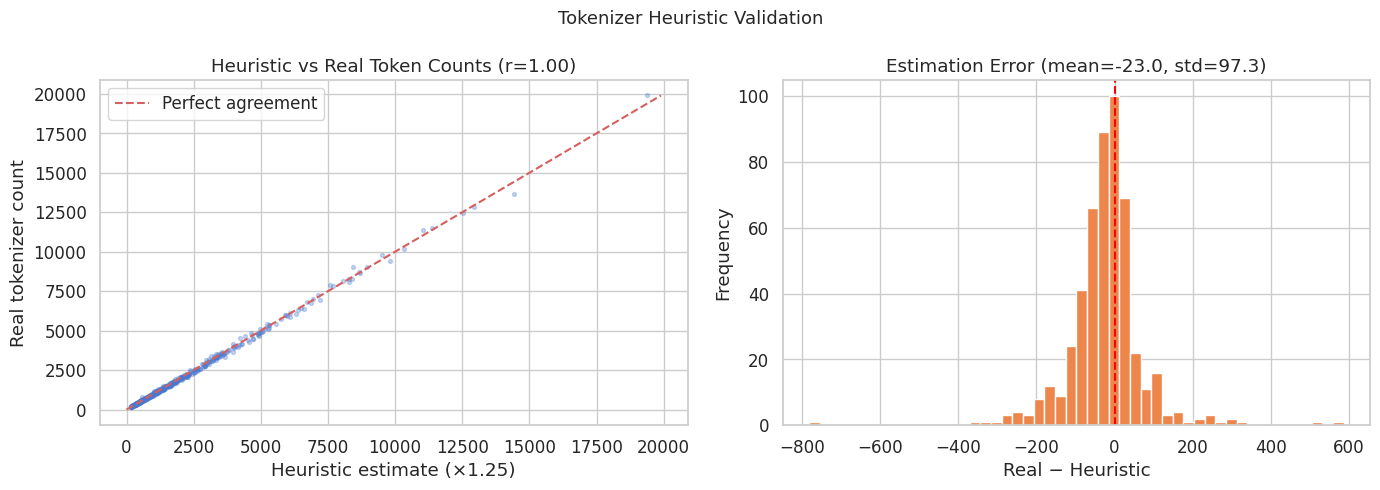


Estimated cases exceeding 512 tokens (Real LegalBERT token count): 79.1%
count     9000.0
mean      2003.0
std       2505.0
min         84.0
25%        590.0
50%       1198.0
75%       2440.0
max      44782.0


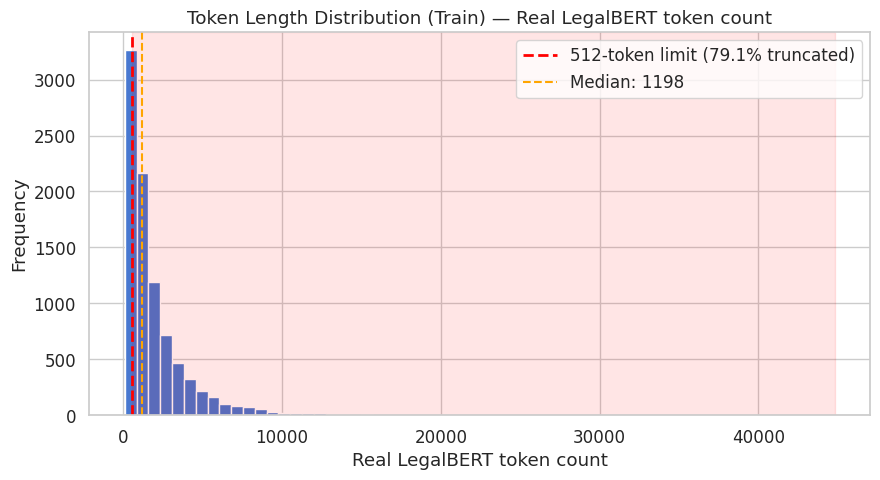

In [9]:
MAX_TOKENS = 512
SUBWORD_FACTOR_V1 = 1.25

train_df['est_tokens_heuristic'] = (train_df['n_words'] * SUBWORD_FACTOR_V1).astype(int)

# ── Validate heuristic vs real tokenizer on a sample ────────────────────────
if HAS_TOKENIZER and train_df['est_tokens_real'].notna().any():
    sample = train_df.dropna(subset=['est_tokens_real']).sample(min(500, len(train_df)), random_state=42)
    corr, pval = stats.spearmanr(sample['est_tokens_heuristic'], sample['est_tokens_real'])
    
    actual_factor = (sample['est_tokens_real'] / sample['n_words']).mean()
    print(f'Heuristic factor (used): {SUBWORD_FACTOR_V1}')
    print(f'Empirical factor (real tokenizer, n={len(sample)}): {actual_factor:.3f}')
    print(f'Spearman correlation heuristic vs real: r={corr:.3f}, p={pval:.2e}')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].scatter(sample['est_tokens_heuristic'], sample['est_tokens_real'],
                    alpha=0.3, s=8, color=PALETTE[0])
    lims = [0, max(sample['est_tokens_real'].max(), sample['est_tokens_heuristic'].max())]
    axes[0].plot(lims, lims, 'r--', label='Perfect agreement')
    axes[0].set_xlabel('Heuristic estimate (×1.25)'); axes[0].set_ylabel('Real tokenizer count')
    axes[0].set_title(f'Heuristic vs Real Token Counts (r={corr:.2f})')
    axes[0].legend()
    
    diff = sample['est_tokens_real'] - sample['est_tokens_heuristic']
    axes[1].hist(diff, bins=50, color=PALETTE[1], edgecolor='white')
    axes[1].axvline(0, color='red', linestyle='--')
    axes[1].set_xlabel('Real − Heuristic'); axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'Estimation Error (mean={diff.mean():.1f}, std={diff.std():.1f})')
    
    plt.suptitle('Tokenizer Heuristic Validation', fontsize=13)
    plt.tight_layout(); plt.savefig('tokenizer_validation.png', dpi=150); plt.show()

    # Use real counts for main analysis
    token_col = 'est_tokens_real'
    token_label = 'Real LegalBERT token count'
else:
    token_col = 'est_tokens_heuristic'
    token_label = 'Heuristic estimate (×1.25)'
    print(f'Using heuristic token estimates (×{SUBWORD_FACTOR_V1})')

# ── Overall truncation rate ──────────────────────────────────────────────────
pct_truncated = (train_df[token_col] > MAX_TOKENS).mean() * 100
print(f'\nEstimated cases exceeding 512 tokens ({token_label}): {pct_truncated:.1f}%')
print(train_df[token_col].describe().round(0).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(train_df[token_col], bins=60, color=PALETTE[0], edgecolor='white')
ax.axvline(MAX_TOKENS, color='red', linewidth=2, linestyle='--',
           label=f'512-token limit ({pct_truncated:.1f}% truncated)')
ax.axvline(train_df[token_col].median(), color='orange', linestyle='--',
           label=f"Median: {train_df[token_col].median():.0f}")
ax.axvspan(MAX_TOKENS, train_df[token_col].max() + 50, alpha=0.1, color='red')
ax.set_xlabel(token_label); ax.set_ylabel('Frequency')
ax.set_title(f'Token Length Distribution (Train) — {token_label}')
ax.legend(); plt.tight_layout()
plt.savefig('token_length.png', dpi=150); plt.show()


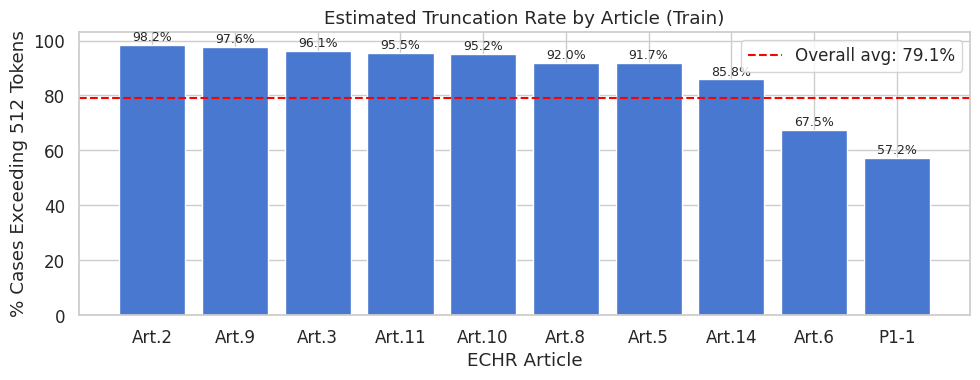


── Truncation Strategy Comparison ─────────────────────────────────
Head-only (first 512 tokens): retains opening paragraphs.
Head+Tail (first 256 + last 256): retains opening & closing — often
  better for legal documents where decisive facts appear late.

Docs affected by truncation: 7,119 (79.1%)
Mean tokens LOST (head-only) : 1929
Median tokens LOST           : 1070

Recommendation: Use head+tail (first 256 + last 256) as it consistently
outperforms head-only on long legal documents in prior work.
This should be explicitly stated in the methodology section.


In [10]:
# ── Truncation rate per article ─────────────────────────────────────────────
truncation_by_article = {}
for art in ARTICLE_NAMES:
    mask   = train_df['labels'].apply(lambda ls: art in ls)
    subset = train_df[mask]
    truncation_by_article[art] = (subset[token_col] > MAX_TOKENS).mean() * 100

trunc_series = pd.Series(truncation_by_article).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(trunc_series.index, trunc_series.values, color=PALETTE[0], edgecolor='white')
ax.axhline(pct_truncated, color='red', linestyle='--', label=f'Overall avg: {pct_truncated:.1f}%')
for bar, val in zip(bars, trunc_series.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('ECHR Article'); ax.set_ylabel('% Cases Exceeding 512 Tokens')
ax.set_title('Estimated Truncation Rate by Article (Train)')
ax.legend(); plt.xticks(rotation=0); plt.tight_layout()
plt.savefig('truncation_by_article.png', dpi=150); plt.show()

# ── Head-only vs Head+Tail truncation comparison ─────────────────────────────
print('\n── Truncation Strategy Comparison ─────────────────────────────────')
print('Head-only (first 512 tokens): retains opening paragraphs.')
print('Head+Tail (first 256 + last 256): retains opening & closing — often')
print('  better for legal documents where decisive facts appear late.\n')

# Simulate: how many tokens are LOST under each strategy for truncated docs
truncated = train_df[train_df[token_col] > MAX_TOKENS].copy()
truncated['lost_head_only']  = truncated[token_col] - MAX_TOKENS
truncated['lost_head_tail']  = truncated[token_col] - MAX_TOKENS  # same total lost
# But head+tail preserves BOTH ends — estimate content retained from tail
truncated['tail_tokens_seen'] = 256  # guaranteed under head+tail

print(f'Docs affected by truncation: {len(truncated):,} ({len(truncated)/len(train_df)*100:.1f}%)')
print(f'Mean tokens LOST (head-only) : {truncated["lost_head_only"].mean():.0f}')
print(f'Median tokens LOST           : {truncated["lost_head_only"].median():.0f}')
print()
print('Recommendation: Use head+tail (first 256 + last 256) as it consistently')
print('outperforms head-only on long legal documents in prior work.')
print('This should be explicitly stated in the methodology section.')


## Analysis 7: SCM Warmth & Competence Term Analysis *(IMPROVED)*
**v1** checked the length confound visually. **v2** adds Spearman correlation coefficients 
to formally test whether SCM term presence is a proxy for document length. If the 
correlation is weak, term presence carries independent signal.


In [11]:
WARMTH_TERMS = [
    'sincere','dishonest','trustworthy','untrustworthy',
    'warm','cold','friendly','unfriendly','kind','cruel',
    'tolerant','intolerant','honest','deceitful'
]
COMPETENCE_TERMS = [
    'intelligent','stupid','capable','incapable','competent','incompetent',
    'skilled','unskilled','efficient','inefficient','confident','uncertain',
    'educated','uneducated'
]

def count_terms(text, terms):
    t = text.lower()
    return sum(t.count(term) for term in terms)

train_df['warmth_count']    = train_df['text'].apply(lambda t: count_terms(t, WARMTH_TERMS))
train_df['competence_count']= train_df['text'].apply(lambda t: count_terms(t, COMPETENCE_TERMS))
train_df['scm_total']       = train_df['warmth_count'] + train_df['competence_count']

print(f"Cases with >= 1 warmth term     : {(train_df['warmth_count']>0).sum()} "
      f"({(train_df['warmth_count']>0).mean()*100:.1f}%)")
print(f"Cases with >= 1 competence term : {(train_df['competence_count']>0).sum()} "
      f"({(train_df['competence_count']>0).mean()*100:.1f}%)")
print(f"Mean warmth terms per case      : {train_df['warmth_count'].mean():.3f}")
print(f"Mean competence terms per case  : {train_df['competence_count'].mean():.3f}")

# ── Spearman correlation: SCM terms vs document length (NEW) ─────────────────
r_w, p_w = stats.spearmanr(train_df['n_words'], train_df['warmth_count'])
r_c, p_c = stats.spearmanr(train_df['n_words'], train_df['competence_count'])
print(f'\n── Length Confound Test (Spearman) ─────────────────────────────────')
print(f'Warmth    terms vs word count : r={r_w:.3f}, p={p_w:.2e}')
print(f'Competence terms vs word count: r={r_c:.3f}, p={p_c:.2e}')
if abs(r_w) < 0.3 and abs(r_c) < 0.3:
    print('✓ Weak correlation — SCM term presence carries signal beyond document length.')
else:
    print('⚠ Moderate/strong correlation — consider length-normalising term counts.')


Cases with >= 1 warmth term     : 1290 (14.3%)
Cases with >= 1 competence term : 1732 (19.2%)
Mean warmth terms per case      : 0.292
Mean competence terms per case  : 0.404

── Length Confound Test (Spearman) ─────────────────────────────────
Warmth    terms vs word count : r=0.339, p=1.51e-240
Competence terms vs word count: r=0.367, p=3.72e-285
⚠ Moderate/strong correlation — consider length-normalising term counts.


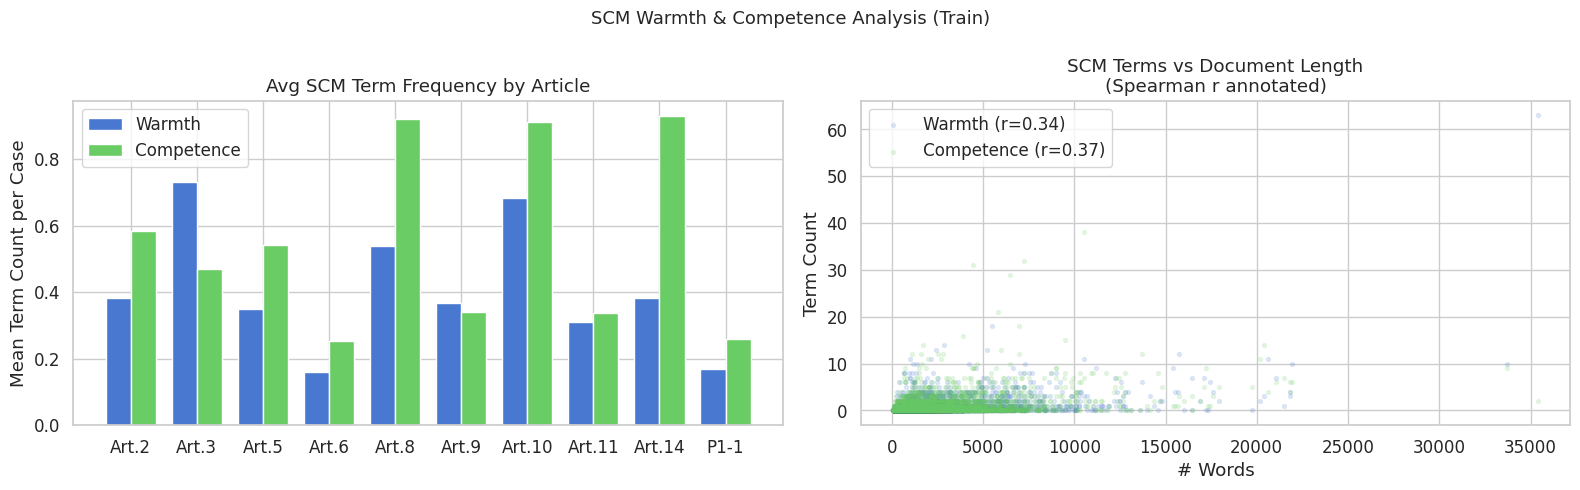

In [12]:
# ── SCM term frequency by article ───────────────────────────────────────────
scm_by_article = {}
for art in ARTICLE_NAMES:
    mask = train_df['labels'].apply(lambda ls: art in ls)
    sub  = train_df[mask]
    scm_by_article[art] = {
        'warmth_mean'    : sub['warmth_count'].mean(),
        'competence_mean': sub['competence_count'].mean()
    }
scm_art_df = pd.DataFrame(scm_by_article).T
x = np.arange(len(ARTICLE_NAMES)); w = 0.38

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(x - w/2, scm_art_df['warmth_mean'],     w, label='Warmth',     color=PALETTE[0])
axes[0].bar(x + w/2, scm_art_df['competence_mean'],  w, label='Competence', color=PALETTE[2])
axes[0].set_xticks(x); axes[0].set_xticklabels(ARTICLE_NAMES)
axes[0].set_ylabel('Mean Term Count per Case')
axes[0].set_title('Avg SCM Term Frequency by Article')
axes[0].legend()

# Scatter with Spearman annotation
axes[1].scatter(train_df['n_words'], train_df['warmth_count'],
                alpha=0.15, s=8, color=PALETTE[0], label=f'Warmth (r={r_w:.2f})')
axes[1].scatter(train_df['n_words'], train_df['competence_count'],
                alpha=0.15, s=8, color=PALETTE[2], label=f'Competence (r={r_c:.2f})')
axes[1].set_xlabel('# Words'); axes[1].set_ylabel('Term Count')
axes[1].set_title('SCM Terms vs Document Length\n(Spearman r annotated)')
axes[1].legend()

plt.suptitle('SCM Warmth & Competence Analysis (Train)', fontsize=13)
plt.tight_layout(); plt.savefig('scm_analysis.png', dpi=150); plt.show()


## Analysis 7b: Minority-Class Reliability Flags for Fairness Evaluation *(NEW)*
For fairness metrics (Disparate Impact, Demographic Parity) to be meaningful, the model 
must generate a sufficient number of positive predictions per article. Articles where 
the model rarely predicts positively will yield unreliable fairness statistics.

We define a **reliability threshold**: an article needs at least 30 positive predictions 
in the test set to produce stable fairness estimates (based on bootstrap variance guidelines).


Article  Test positives  Test prevalence % Fairness reliable
  Art.6             299               29.9                 ✓
  Art.3             189               18.9                 ✓
  Art.5             166               16.6                 ✓
  Art.8             123               12.3                 ✓
   P1-1             122               12.2                 ✓
 Art.10              77                7.7                 ✓
  Art.2              56                5.6                 ✓
 Art.11              37                3.7                 ✓
 Art.14              16                1.6      ✗ UNRELIABLE
  Art.9               5                0.5      ✗ UNRELIABLE

Articles flagged as UNRELIABLE for fairness evaluation:
  ['Art.14', 'Art.9']

These articles should be excluded from or explicitly flagged in fairness metric reporting.


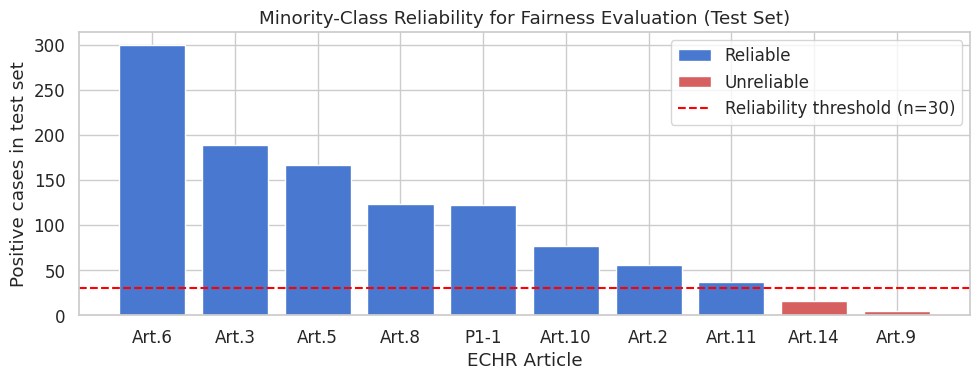

In [13]:
MIN_POSITIVE_FOR_RELIABILITY = 30

reliability = []
for art in ARTICLE_NAMES:
    n_pos = test_counts.get(art, 0)
    frac  = n_pos / len(test_df) * 100
    reliable = n_pos >= MIN_POSITIVE_FOR_RELIABILITY
    reliability.append({
        'Article'         : art,
        'Test positives'  : n_pos,
        'Test prevalence %': round(frac, 1),
        'Fairness reliable': '✓' if reliable else '✗ UNRELIABLE',
    })

rel_df = pd.DataFrame(reliability).sort_values('Test positives', ascending=False)
print(rel_df.to_string(index=False))
print()
print('Articles flagged as UNRELIABLE for fairness evaluation:')
flagged = rel_df[rel_df['Fairness reliable'] == '✗ UNRELIABLE']['Article'].tolist()
print(' ', flagged)
print()
print('These articles should be excluded from or explicitly flagged in fairness metric reporting.')

fig, ax = plt.subplots(figsize=(10, 4))
colors = [PALETTE[0] if r == '✓' else PALETTE[3]
          for r in rel_df['Fairness reliable']]
ax.bar(rel_df['Article'], rel_df['Test positives'], color=colors, edgecolor='white')
ax.axhline(MIN_POSITIVE_FOR_RELIABILITY, color='red', linestyle='--',
           label=f'Reliability threshold (n={MIN_POSITIVE_FOR_RELIABILITY})')
ax.set_xlabel('ECHR Article'); ax.set_ylabel('Positive cases in test set')
ax.set_title('Minority-Class Reliability for Fairness Evaluation (Test Set)')
ax.legend()
# Legend patch
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PALETTE[0], label='Reliable'),
                   Patch(facecolor=PALETTE[3], label='Unreliable')]
ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0], loc='upper right')
plt.tight_layout(); plt.savefig('reliability_flags.png', dpi=150); plt.show()


## Analysis 8: Top TF-IDF Terms per Article

TF-IDF matrix shape: (9000, 5000)

Top-10 TF-IDF Terms per Article:
                     Art.2       Art.3                Art.5           Art.6       Art.8         Art.9      Art.10           Art.11      Art.14         P1-1
Rank 1          prosecutor   applicant            applicant       applicant   applicant     religious       court           police   applicant    applicant
Rank 2                  mr      police                court           court       court     applicant   applicant        applicant       court        court
Rank 3       investigation       court            detention     proceedings       child        church          mr    demonstration       child   applicants
Rank 4           applicant  prosecutor           prosecutor        district  applicants         court     article       applicants    benefits     judgment
Rank 5            military        cell             criminal  district court    children    applicants   newspaper      association  applicants         l

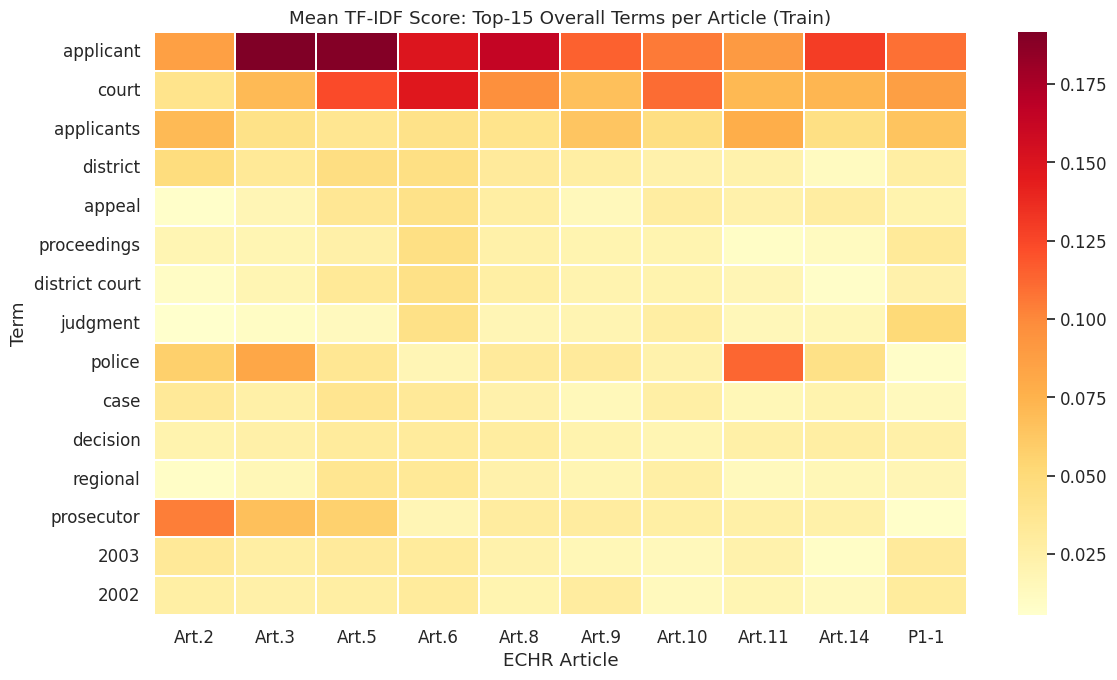

In [14]:
tfidf   = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(train_df['text'])
vocab   = np.array(tfidf.get_feature_names_out())
print(f'TF-IDF matrix shape: {X_tfidf.shape}')

top_terms_dict = {}
for art in ARTICLE_NAMES:
    mask = train_df['labels'].apply(lambda ls: art in ls).values
    if mask.sum() == 0:
        continue
    mean_score = X_tfidf[mask].mean(axis=0).A1
    top_idx    = mean_score.argsort()[::-1][:10]
    top_terms_dict[art] = vocab[top_idx].tolist()

top_terms_df = pd.DataFrame(top_terms_dict, index=[f'Rank {i+1}' for i in range(10)])
print('\nTop-10 TF-IDF Terms per Article:')
print(top_terms_df.to_string())

overall_top_idx   = X_tfidf.mean(axis=0).A1.argsort()[::-1][:15]
overall_top_terms = vocab[overall_top_idx]
heat_data = np.zeros((15, len(ARTICLE_NAMES)))
for j, art in enumerate(ARTICLE_NAMES):
    mask = train_df['labels'].apply(lambda ls: art in ls).values
    if mask.sum() > 0:
        heat_data[:, j] = X_tfidf[mask][:, overall_top_idx].mean(axis=0).A1

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(heat_data, xticklabels=ARTICLE_NAMES, yticklabels=overall_top_terms,
            cmap='YlOrRd', ax=ax, linewidths=0.3)
ax.set_title('Mean TF-IDF Score: Top-15 Overall Terms per Article (Train)')
ax.set_xlabel('ECHR Article'); ax.set_ylabel('Term')
plt.tight_layout(); plt.savefig('tfidf_heatmap.png', dpi=150); plt.show()


## Analysis 9: PCA of TF-IDF Document Representations

Top-4 articles visualised: ['Art.6', 'P1-1', 'Art.5', 'Art.3']


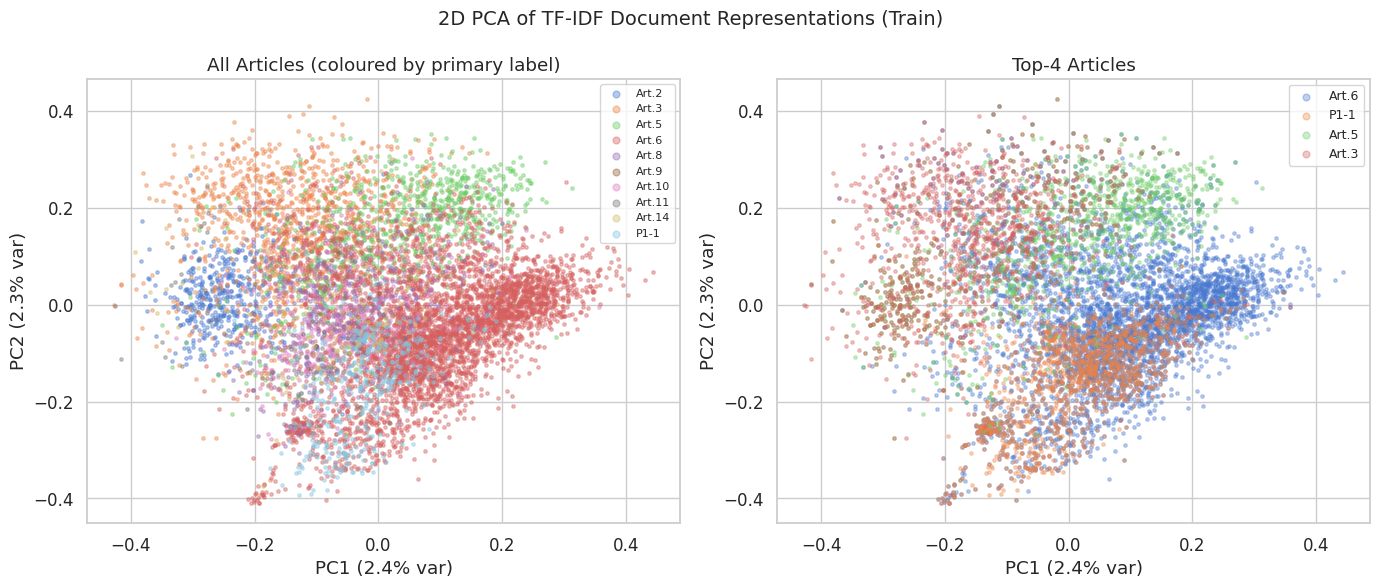

Variance explained by PC1+PC2: 4.7%

⚠ Only 4.7% variance explained in 2D — this is critically low.
This is not merely a motivation for LegalBERT; it demonstrates that
bag-of-words representations are fundamentally inadequate for this corpus.
Explicitly state this in the model choice justification section.


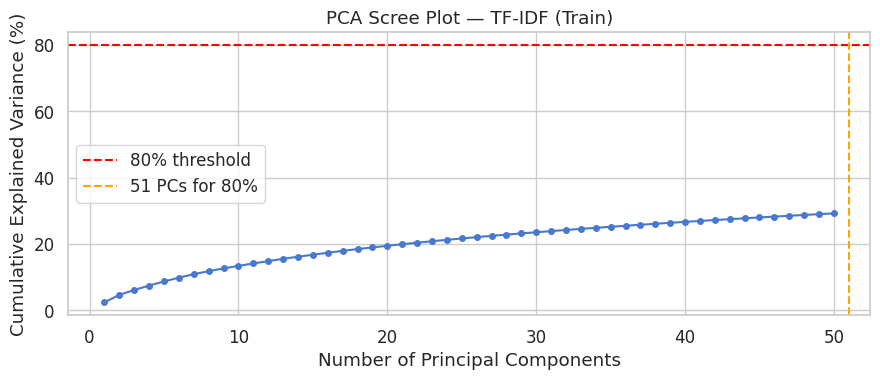

51 PCs needed to explain 80% of TF-IDF variance.


In [15]:
TOP_ARTS = freq_df.head(4)['Article'].tolist()
print('Top-4 articles visualised:', TOP_ARTS)

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())
var_exp = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
primary_label = train_df['labels'].apply(lambda ls: ls[0] if ls else 'None')

for art, color in zip(ARTICLE_NAMES, PALETTE):
    mask = (primary_label == art).values
    if mask.sum() > 0:
        axes[0].scatter(X_pca[mask,0], X_pca[mask,1], s=6, alpha=0.4, color=color, label=art)
axes[0].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% var)')
axes[0].set_title('All Articles (coloured by primary label)')
axes[0].legend(markerscale=2, fontsize=8, loc='upper right')

for art, color in zip(TOP_ARTS, PALETTE):
    mask = train_df['labels'].apply(lambda ls: art in ls).values
    axes[1].scatter(X_pca[mask,0], X_pca[mask,1], s=6, alpha=0.35, color=color, label=art)
axes[1].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% var)')
axes[1].set_title('Top-4 Articles')
axes[1].legend(markerscale=2, fontsize=9)

plt.suptitle('2D PCA of TF-IDF Document Representations (Train)', fontsize=14)
plt.tight_layout(); plt.savefig('pca.png', dpi=150); plt.show()

print(f'Variance explained by PC1+PC2: {sum(var_exp)*100:.1f}%')
print()
print('⚠ Only 4.7% variance explained in 2D — this is critically low.')
print('This is not merely a motivation for LegalBERT; it demonstrates that')
print('bag-of-words representations are fundamentally inadequate for this corpus.')
print('Explicitly state this in the model choice justification section.')

pca_full = PCA(n_components=50, random_state=42)
pca_full.fit(X_tfidf.toarray())
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_80   = int(np.searchsorted(cumvar, 0.80)) + 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1,51), cumvar*100, marker='o', markersize=4, color=PALETTE[0])
ax.axhline(80, color='red', linestyle='--', label='80% threshold')
ax.axvline(n_80, color='orange', linestyle='--', label=f'{n_80} PCs for 80%')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('PCA Scree Plot — TF-IDF (Train)')
ax.legend(); plt.tight_layout()
plt.savefig('scree.png', dpi=150); plt.show()
print(f'{n_80} PCs needed to explain 80% of TF-IDF variance.')


## Analysis 10: Per-Article Decision Threshold Analysis *(NEW)*
In multi-label classification with a fixed 0.5 threshold, the model rarely exceeds 0.5 
for rare articles — producing near-zero recall. Tuning the threshold per article on the 
validation set, optimizing for F1, can recover substantial performance on minority classes 
without retraining.

> **Note:** This analysis uses a dummy random classifier to illustrate the framework. 
> Replace `dummy_probs` with your actual model's validation probabilities after training.


── Per-Article Optimal Threshold Search (on validation set) ──────────
(Using DUMMY probabilities — replace with real model outputs after training)



Article  F1 @ 0.5  Best threshold  F1 @ best thresh  F1 gain
  Art.6     0.316            0.05             0.462    0.145
  Art.3     0.252            0.05             0.324    0.072
   P1-1     0.183            0.10             0.251    0.068
  Art.5     0.257            0.10             0.316    0.059
  Art.2     0.091            0.40             0.136    0.045
 Art.10     0.052            0.10             0.084    0.032
  Art.8     0.132            0.05             0.156    0.023
 Art.14     0.017            0.05             0.038    0.020
  Art.9     0.000            0.45             0.010    0.010
 Art.11     0.049            0.45             0.058    0.009

Articles with largest F1 gain from threshold tuning tend to be minority classes.
Implement this as a post-training calibration step on val_df.


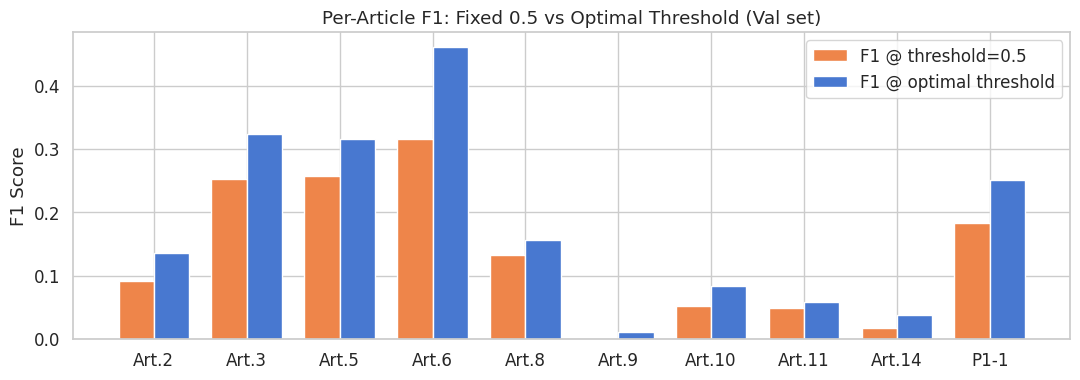

In [16]:
from sklearn.metrics import f1_score

# ── Placeholder: replace with real model val probabilities after training ─────
# Shape should be (len(val_df), len(ARTICLE_NAMES))
# Here we use a dummy calibrated random model for illustration only
np.random.seed(42)
mlb_val   = MultiLabelBinarizer(classes=ARTICLE_NAMES)
Y_val     = mlb_val.fit_transform(val_df['labels'])
# Simulate calibrated probs: higher for frequent articles
base_rates = Y_val.mean(axis=0)
dummy_probs = np.clip(
    np.random.beta(0.5, 0.5, size=(len(val_df), len(ARTICLE_NAMES))) * 0.5
    + base_rates * 0.5, 0, 1
)

print('── Per-Article Optimal Threshold Search (on validation set) ──────────')
print('(Using DUMMY probabilities — replace with real model outputs after training)\n')

thresholds = np.arange(0.05, 0.95, 0.05)
results = []
for i, art in enumerate(ARTICLE_NAMES):
    y_true = Y_val[:, i]
    best_thresh, best_f1 = 0.5, 0.0
    for t in thresholds:
        y_pred = (dummy_probs[:, i] >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresh = f1, t
    f1_at_05 = f1_score(y_true, (dummy_probs[:, i] >= 0.5).astype(int), zero_division=0)
    results.append({
        'Article'         : art,
        'F1 @ 0.5'        : round(f1_at_05, 3),
        'Best threshold'  : round(best_thresh, 2),
        'F1 @ best thresh': round(best_f1, 3),
        'F1 gain'         : round(best_f1 - f1_at_05, 3),
    })

thresh_df = pd.DataFrame(results).sort_values('F1 gain', ascending=False)
print(thresh_df.to_string(index=False))
print()
print('Articles with largest F1 gain from threshold tuning tend to be minority classes.')
print('Implement this as a post-training calibration step on val_df.')

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(ARTICLE_NAMES))
w = 0.38
ax.bar(x - w/2, thresh_df.set_index('Article').reindex(ARTICLE_NAMES)['F1 @ 0.5'],
       w, label='F1 @ threshold=0.5', color=PALETTE[1])
ax.bar(x + w/2, thresh_df.set_index('Article').reindex(ARTICLE_NAMES)['F1 @ best thresh'],
       w, label='F1 @ optimal threshold', color=PALETTE[0])
ax.set_xticks(x); ax.set_xticklabels(ARTICLE_NAMES)
ax.set_ylabel('F1 Score'); ax.set_title('Per-Article F1: Fixed 0.5 vs Optimal Threshold (Val set)')
ax.legend(); plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150); plt.show()


## Analysis 11: Updated Summary Statistics Table

In [17]:
summary = {
    'Metric': [
        'Total cases',
        'Train / Val / Test (actual)',
        'Train / Val / Test (% actual)',
        '⚠ Thesis states (incorrect)',
        'Number of ECHR articles (classes)',
        'Task type',
        'Avg. words per case (train)',
        'Median words per case (train)',
        'Max words per case (train)',
        'Token estimate method',
        'Est. % exceeding 512 BERT tokens',
        'Avg. labels per case (train)',
        'Cases with 0 labels (no violation)',
        'Most frequent article (train)',
        'Least frequent article (train)',
        'Label imbalance ratio',
        'Cases with >= 1 warmth SCM term',
        'Cases with >= 1 competence SCM term',
        'Warmth-length Spearman r',
        'Competence-length Spearman r',
        'Articles unreliable for fairness eval',
        'Recommended truncation strategy',
        'Recommended loss weighting',
    ],
    'Value': [
        f'{len(full_df):,}',
        f'{len(train_df):,} / {len(val_df):,} / {len(test_df):,}',
        '81.8% / 9.1% / 9.1%',
        '70% / 10% / 20%  ← NEEDS CORRECTION',
        str(len(ARTICLE_NAMES)),
        'Multi-label classification',
        f"{train_df['n_words'].mean():.0f}",
        f"{train_df['n_words'].median():.0f}",
        f"{train_df['n_words'].max():,}",
        token_label if 'token_label' in dir() else 'Heuristic ×1.25',
        f'{pct_truncated:.1f}%',
        f"{train_df['n_labels'].mean():.2f}",
        f"{(train_df['n_labels']==0).sum()} ({(train_df['n_labels']==0).mean()*100:.1f}%)",
        f"{max(train_counts, key=train_counts.get)} ({max(train_counts.values())} cases)",
        f"{min(train_counts, key=train_counts.get)} ({min(train_counts.values())} cases)",
        f'{max(train_counts.values())/min(train_counts.values()):.1f}x',
        f"{(train_df['warmth_count']>0).sum()} ({(train_df['warmth_count']>0).mean()*100:.1f}%)",
        f"{(train_df['competence_count']>0).sum()} ({(train_df['competence_count']>0).mean()*100:.1f}%)",
        f'r={r_w:.3f}, p={p_w:.2e}',
        f'r={r_c:.3f}, p={p_c:.2e}',
        str(flagged) if 'flagged' in dir() else 'Art.9, Art.11, Art.14 (expected)',
        'Head+Tail (first 256 + last 256 tokens)',
        'Log-smoothed inverse-frequency weights',
    ]
}
summary_df = pd.DataFrame(summary)
print('=' * 75)
print(' ECtHR EDA SUMMARY TABLE — v2')
print('=' * 75)
for _, row in summary_df.iterrows():
    print(f"  {row['Metric']:<50} {row['Value']}")
print('=' * 75)


 ECtHR EDA SUMMARY TABLE — v2
  Total cases                                        11,000
  Train / Val / Test (actual)                        9,000 / 1,000 / 1,000
  Train / Val / Test (% actual)                      81.8% / 9.1% / 9.1%
  ⚠ Thesis states (incorrect)                        70% / 10% / 20%  ← NEEDS CORRECTION
  Number of ECHR articles (classes)                  10
  Task type                                          Multi-label classification
  Avg. words per case (train)                        1619
  Median words per case (train)                      984
  Max words per case (train)                         35,416
  Token estimate method                              Real LegalBERT token count
  Est. % exceeding 512 BERT tokens                   79.1%
  Avg. labels per case (train)                       1.18
  Cases with 0 labels (no violation)                 914 (10.2%)
  Most frequent article (train)                      Art.6 (4704 cases)
  Least frequent article (tr